## Plotting a range of PDFs vertical distributions of eatin gand precip from TRBELT simulations

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as mp
from matplotlib import cm
from matplotlib.colors import ListedColormap

import os
import glob as gb

from dask.distributed import Client
from ncar_jobqueue import NCARCluster


In [2]:
from distributed import Client
from ncar_jobqueue import NCARCluster

cluster = NCARCluster(account='P93300042',interface='ext', job_extra_directives=[],walltime ='12:00:00')
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/45903/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/45903/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:41255,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/45903/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [26]:
dir0 = '/glade/derecho/scratch/rneale/archive/'


#### RUN INFO ####

fig_sub = 'zm_cam7_zmpbl+ke'

cases = ['CAM7','CAM7-noZMPBL','+KE(TKE)','+dmpdz(1e-4)']
runs = ['f.cam6_4_032.FLTHIST_ne30.cam7_dev.002','f.cam6_4_032.FLTHIST_ne30.cam7_dev.003','f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b']


#cases = ['CAM7','+KE','+KE(TKE)','+dmpdz(1e-4)']
#runs = ['f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a','f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.004b']

#cases = ['CAM7','+KE','+KE(TKE)','+dmpdz(1e-4)']

#runs = ['f.cam6_4_032.FLTHIST_ne30.cam7_dev.002','f.cam6_4_032.FLTHIST_ne30.cam7_dev.005','f.cam6_4_032.FLTHIST_ne30.cam7_dev.006','f.cam6_4_032.FLTHIST_ne30.cam7_dev.007','f.cam6_4_032.FLTHIST_ne30.cam7_dev.008']
#cases = ['CAM7(0.7/0.1)','+cmt.0.4','+cmt.0.1','+alfa.0.05','+alfa.0.25']


#runs = ['f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a','f.cam6_4_032.FLTHIST_ne30.cam7_ke.005b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.006b','f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b']
 

#### REGIONS ###

reg_name = "Tropics" ; lat_lims = [-15,15]  ; lon_lims = [120,150]
#reg_name = "ACCLIP"  ; lat_lims = [30.,45.]  ; lon_lims = [95.,125.]
#reg_name = "Monsoon Pacific" ; lat_lims = [15,50]  ; lon_lims = [120,150]
#ßreg_name = "Central USA" ; lat_lims [] ; lon_lims = []


period = '200?-01' ; period_name = 'January'
#period = '200?-07' ; period_name = 'July'
#period = '000?-04' ; period_name = 'April'

ldiff = True


#### Model Data Frequency ####

#channel = 'h0a' ; cfreq = 'monthly' # Frequency=monthly or daily
#channel = 'h1a' ; cfreq = 'daily' # Frequency=monthly or daily


#### 3D Dependent variable ####

#var_3d = 'DTCOND'  ;  v3d_units = 'K/day' ; v3d_scale = 86400. ; clev_scale = [1.5,0.4] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
var_3d = 'ZMDT'  ;  v3d_units = 'K/day' ; v3d_scale = 86400. ; clev_scale = [1,0.5] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'ZMDQ'  ;  v3d_units = 'g/kg/day' ; v3d_scale = 1000.*86400. ; clev_scale = [0.5,0.25] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'ZMMU'  ;  v3d_units = 'kg/m^2/hr' ; v3d_scale = 3600. ; clev_scale = [5.,4] ; clev_offset = [10.,0.] ; cont_cbar = ['Purples','PuOr']
#var_3d = 'ZMMD'  ;  v3d_units = 'kg/m^2/hr' ; v3d_scale = 3600. ; clev_scale = [0.5,0.5] ; clev_offset = [-10.,0.] ; cont_cbar = ['Purples_r','PuOr']

#var_3d = 'KEPAR'  ;  v3d_units = 'J/kg' ; v3d_scale = 1. ; clev_scale = [5,5] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']

#var_3d = 'BUOY'  ;  v3d_units = 'K' ; v3d_scale = 1. ; clev_scale = [0.1,0.1] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']

#var_3d = 'STEND_CLUBB'  ;  v3d_units = 'K/day' ; v3d_scale = 86400./1000. ; clev_scale = [0.5,0.25] ; clev_offset = [0.,0.] ; cont_cbar = ['RdBu_r','RdBu_r']
#var_3d = 'RELHUM'  ;  v3d_units = '%'     ; v3d_scale = 1. ; clev_scale = [5.,2.] ; clev_offset = [10.,0.] ; cont_cbar = ['Purples','PuOr']



#### 2D Independent Variable ####

#var_2d = 'PRECT'   ;  v2d_units = 'mm/day' ; v2d_scale = 86400.*1000.
var_2d = 'PRECC'   ;  v2d_units = 'mm/day' ; v2d_scale = 86400.*1000.
#var_2d = 'PRECL'   ;  v2d_units = 'mm/day' ; v2d_scale = 86400.*1000.


/glade/derecho/scratch/rneale/tmp/ipykernel_105156/1824929676.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.4)



---- X 2D variable = PRECC ----
---- X,Y 3D variable = ZMDT ----
---- Calculating differences is  True  ----
---- Data Frequency is = daily ----
---- Location (lat/lon) = Tropics_(15S-15N : 120E-150E)



---- CASE = CAM7 ----
/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002.cam.h1a.200?-01*nc
First = /glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002.cam.h1a.2000-01-02-00000.nc
Last  = /glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002/atm/hist/f.cam6_4_032.FLTHIST_ne30.cam7_dev.002.cam.h1a.2006-01-27-00000.nc
          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 8.950257912660257
          ibin,binmin,binmax,cum %age ==  1 0.5 1 6.156308426816239
          ibin,binmin,binmax,cum %age ==  2 1 1.5 4.430317674946581
          ibin,binmin,binmax,cum %age ==  3 1.5 2 3.536804720886752
          ibin,binmin,binmax,cum 

/glade/derecho/scratch/rneale/tmp/ipykernel_105156/1824929676.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 11.664599867724867
          ibin,binmin,binmax,cum %age ==  1 0.5 1 8.172588045634921
          ibin,binmin,binmax,cum %age ==  2 1 1.5 5.946490575396825
          ibin,binmin,binmax,cum %age ==  3 1.5 2 4.757771164021164
          ibin,binmin,binmax,cum %age ==  4 2 2.5 3.968718998015873
          ibin,binmin,binmax,cum %age ==  5 2.5 3 3.4104766038359786
          ibin,binmin,binmax,cum %age ==  6 3 3.5 2.9562975363756614
          ibin,binmin,binmax,cum %age ==  7 3.5 4 2.591559193121693
          ibin,binmin,binmax,cum %age ==  8 4 4.5 2.2687768683862433
          ibin,binmin,binmax,cum %age ==  9 4.5 5 2.03125
          ibin,binmin,binmax,cum %age ==  10 5 6 3.423445767195767
          ibin,binmin,binmax,cum %age ==  11 6 7 2.7055948247354498
          ibin,binmin,binmax,cum %age ==  12 7 8 2.1177972056878307
          ibin,binmin,binmax,cum %age ==  13 8 9 1.6733837632275133
          ibin,binmin,binmax,cum %age ==  14 9 10 1.2

/glade/derecho/scratch/rneale/tmp/ipykernel_105156/1824929676.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 8.589616402116402
          ibin,binmin,binmax,cum %age ==  1 0.5 1 6.192336309523809
          ibin,binmin,binmax,cum %age ==  2 1 1.5 4.7377748842592595
          ibin,binmin,binmax,cum %age ==  3 1.5 2 3.9988942625661377
          ibin,binmin,binmax,cum %age ==  4 2 2.5 3.4919601521164023
          ibin,binmin,binmax,cum %age ==  5 2.5 3 3.10567542989418
          ibin,binmin,binmax,cum %age ==  6 3 3.5 2.8429852843915344
          ibin,binmin,binmax,cum %age ==  7 3.5 4 2.5894407242063493
          ibin,binmin,binmax,cum %age ==  8 4 4.5 2.3626612103174605
          ibin,binmin,binmax,cum %age ==  9 4.5 5 2.162078373015873
          ibin,binmin,binmax,cum %age ==  10 5 6 3.7708746693121693
          ibin,binmin,binmax,cum %age ==  11 6 7 3.162099041005291
          ibin,binmin,binmax,cum %age ==  12 7 8 2.6501012731481484
          ibin,binmin,binmax,cum %age ==  13 8 9 2.2056361607142856
          ibin,binmin,binmax,cum %age ==  

/glade/derecho/scratch/rneale/tmp/ipykernel_105156/1824929676.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


          ibin,binmin,binmax,cum %age ==  0 0.1 0.5 8.50647941468254
          ibin,binmin,binmax,cum %age ==  1 0.5 1 6.071325231481482
          ibin,binmin,binmax,cum %age ==  2 1 1.5 4.6242559523809526
          ibin,binmin,binmax,cum %age ==  3 1.5 2 3.8529265873015874
          ibin,binmin,binmax,cum %age ==  4 2 2.5 3.3912037037037037
          ibin,binmin,binmax,cum %age ==  5 2.5 3 3.043051421957672
          ibin,binmin,binmax,cum %age ==  6 3 3.5 2.7744708994708995
          ibin,binmin,binmax,cum %age ==  7 3.5 4 2.542731068121693
          ibin,binmin,binmax,cum %age ==  8 4 4.5 2.31403976521164
          ibin,binmin,binmax,cum %age ==  9 4.5 5 2.1458023313492065
          ibin,binmin,binmax,cum %age ==  10 5 6 3.763847552910053
          ibin,binmin,binmax,cum %age ==  11 6 7 3.1825086805555554
          ibin,binmin,binmax,cum %age ==  12 7 8 2.6864252645502646
          ibin,binmin,binmax,cum %age ==  13 8 9 2.2484188988095237
          ibin,binmin,binmax,cum %age ==  14

/glade/derecho/scratch/rneale/tmp/ipykernel_105156/1824929676.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mod = cm.get_cmap(cmap)


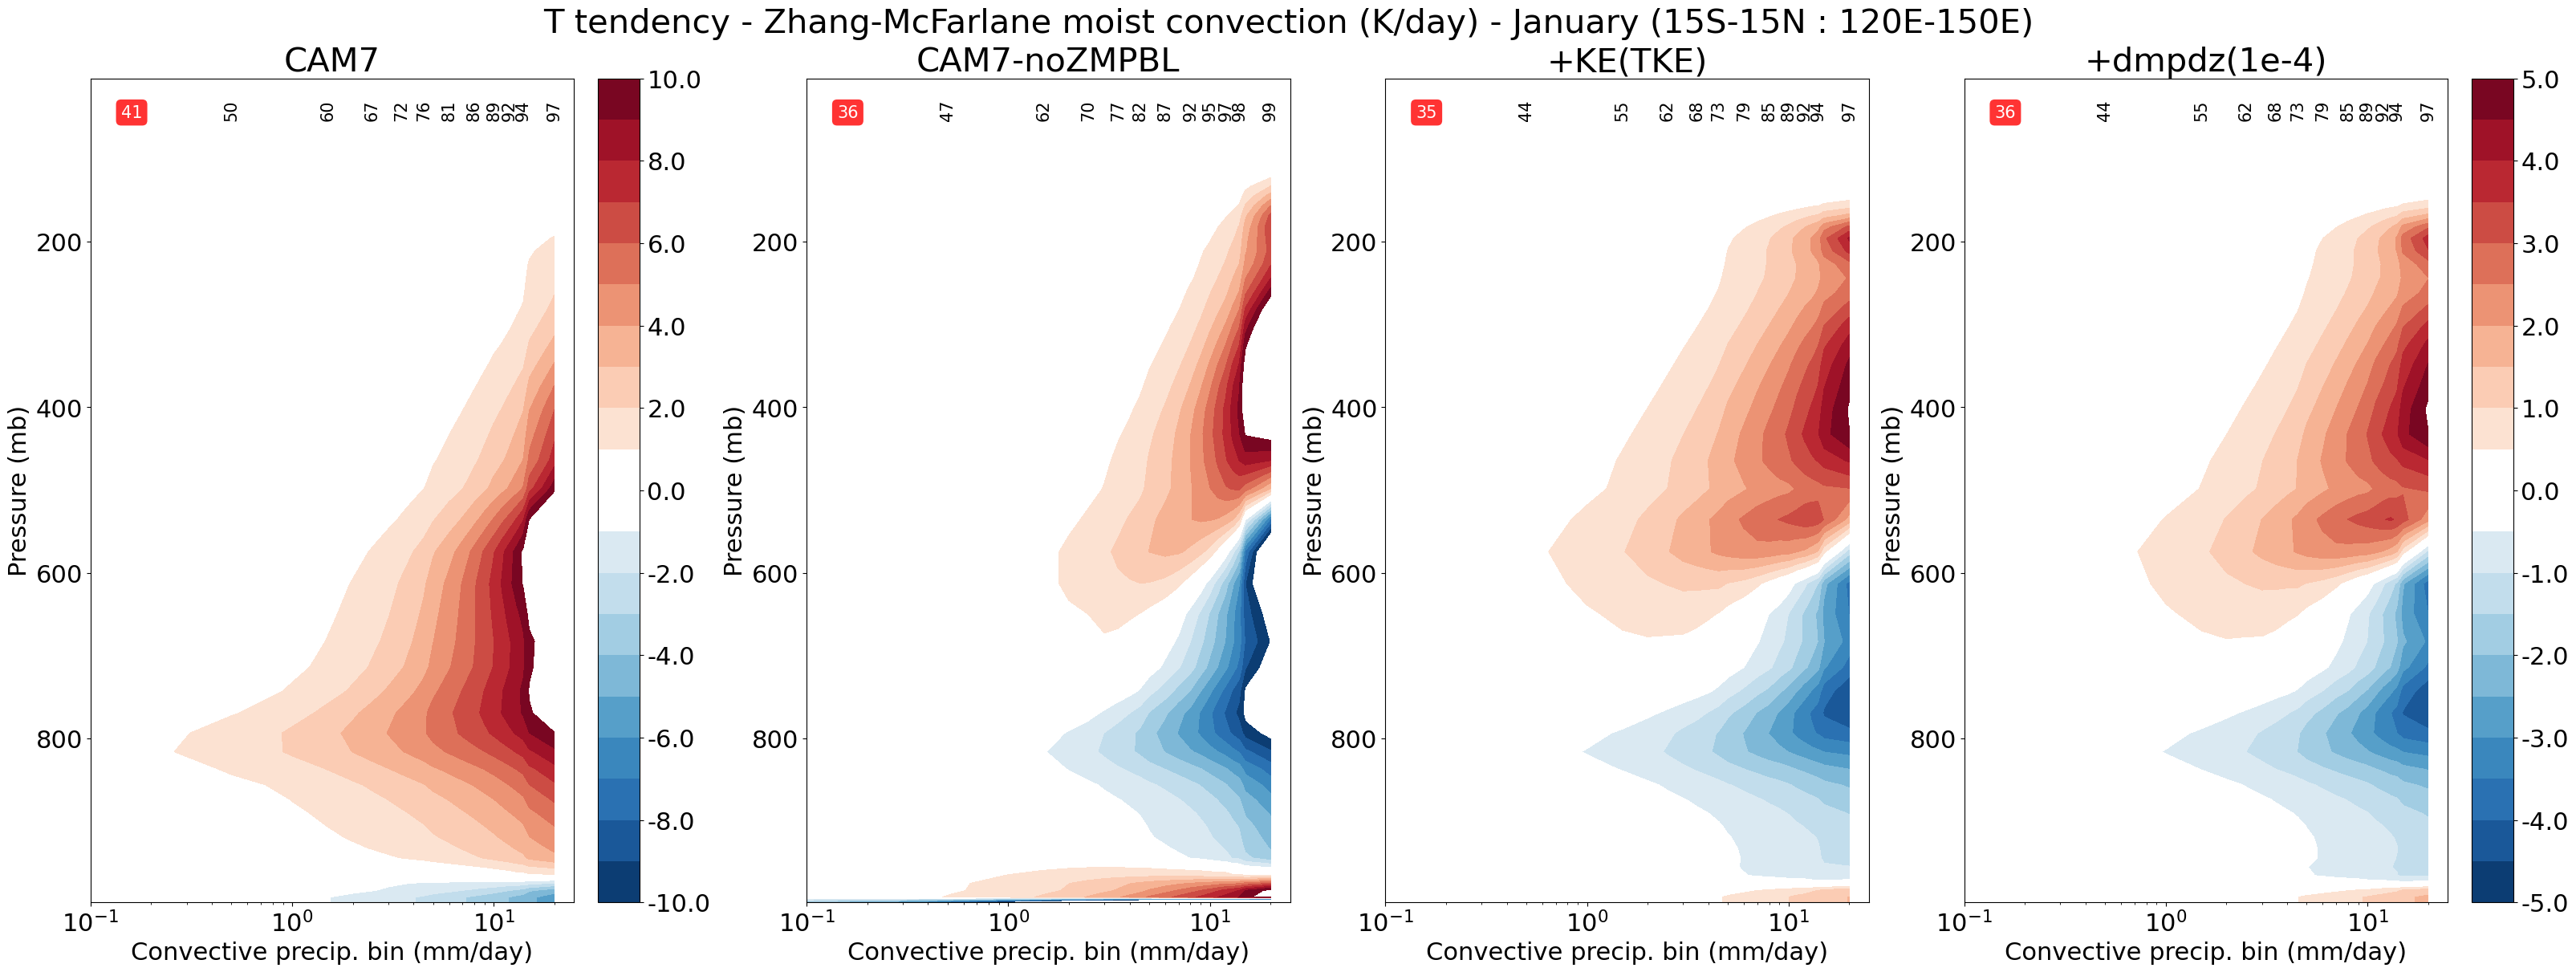

In [27]:
# Directories
dir_fig  = '/glade/u/home/rneale/python/python-figs/zm_dev/'


# Set up figure variables 
ncases = len(cases)
plt, ax1 = mp.subplots(1, ncases, figsize=(32,12), constrained_layout=True)
plt.subplots_adjust(wspace=0.4) 

cb_skip = 2

if var_2d in ['PRECC','PRECT']:
#    bins_x = [0.1,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,20,25,30,50]
    bins_x = [0.1,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10,11,12,13,14,15,20,25]


clevels0 = [-10.,-9.,-8.,-7.,-6.,-5.,-4.,-3.,-2.,-1.,0.,1.,2.,3.,4.,5.,6.,7.,8.,9.,10.]



yname = 'Pressure (mb)'

reg_dom  = '('+str(abs(lat_lims[0]))+'N-' if lat_lims[0] >= 0 else '('+str(abs(lat_lims[0]))+'S-'
reg_dom += str(abs(lat_lims[1]))+'N : ' if lat_lims[1] >= 0 else str(abs(lat_lims[0]))+'S : '

if (ll >0 for ll in lat_lims):
    reg_dom += str(abs(lon_lims[0]))+'E-'
    reg_dom += str(abs(lon_lims[1]))+'E)'


#Construct lat/lon name



print('')
print('---- X 2D variable = '+var_2d+ ' ----')
print('---- X,Y 3D variable = '+var_3d+ ' ----')
print('---- Calculating differences is ',ldiff,' ----')
print('---- Data Frequency is = '+cfreq+ ' ----')
print('---- Location (lat/lon) = '+reg_name+'_'+reg_dom)
print('')
print('')

# Loop cases

for it,trun in enumerate(runs):


    dir_in = dir0+trun+'/atm/hist/'
    print('')
    print('---- CASE = '+cases[it]+ ' ----')

    print(dir_in+trun+'.cam.'+channel+'.'+period+'*nc')
    fhist_h = sorted(gb.glob(dir_in+trun+'.cam.'+channel+'.'+period+'*nc'))
    print('First = '+fhist_h[0])
    print('Last  = '+fhist_h[-1])
    
#    run_path = dir0+trun+'.cam.h0.'+yr_mn+'.nc'
    ds_case = xr.open_mfdataset(fhist_h,parallel=True)   
    ds_case = ds_case.sel(lat=slice(lat_lims[0],lat_lims[1]))
    
    da_3d_var = ds_case[var_3d]

  
    
    
    match (var_2d):
        case('PRECT'):
            xname = 'Total precip. bin (mm/day)'
            if var_2d in ds_case:     da_2d_var = ds_case['PRECT'] 
            if var_2d not in ds_case: da_2d_var = ds_case['PRECC']+ds_case['PRECL'] 
        case('PRECC'):
            xname = 'Convective precip. bin (mm/day)'
            if var_2d in ds_case:     da_2d_var = ds_case['PRECC'] 
            if var_2d not in ds_case: da_2d_var = ds_case['PRECT']-ds_case['PRECL'] 
        case('PRECL'):
            xname = 'Large scale precip. bin (mm/day)'
            if var_2d in ds_case:     da_2d_var = ds_case['PRECL'] 
            if var_2d not in ds_case: da_2d_var = ds_case['PRECT']-ds_case['PRECC'] 

    
    da_2d_var = da_2d_var.compute()*v2d_scale
    da_3d_var = da_3d_var.compute()*v3d_scale
    
    # New plot array creation (with zeros)
    xy_cond = xr.zeros_like(da_2d_var)
    xyp_cond = xr.zeros_like(da_3d_var)
   
    # Set up plot array
    coords = {'lev':da_3d_var.lev.values,'bin':bins_x}
    da_plot_var = xr.DataArray(data=np.full((len(da_3d_var.lev.values),len(bins_x)),np.nan),coords=coords,dims=['lev','bin']) 

    # Unroll input array
    da_3d_var_timelatlon = da_3d_var.stack(time_lat_lon=("time", "lat", "lon"))  
 
    gps_total = da_2d_var.size
    
    # Loop bins to construct averaged profile

    pcent_bin = []

    # Percentage below the lowest bin level
    xy_cond.values = np.logical_and(da_2d_var>=0, da_2d_var<bins_x[0])
    gps_bin0 = xy_cond.values.sum()
    pcent_zero = 100.*gps_bin0/gps_total
    
    
    for ix in range(0,len(bins_x[:-1])):
 
        xy_cond.values = np.logical_and(da_2d_var>=bins_x[ix], da_2d_var<bins_x[ix+1])

        gps_bin = xy_cond.values.sum()
        pcent_bin.append(100.*gps_bin/gps_total)
                                                                                                    
        print('          ibin,binmin,binmax,cum %age == ',ix,bins_x[ix],bins_x[ix+1],pcent_bin[ix])
        
        xy_cond_timelatlon = xy_cond.stack(time_lat_lon=("time", "lat", "lon")) # Flatten to 1D array
        
        da_plot_var[:,ix] = da_3d_var_timelatlon[:,xy_cond_timelatlon].mean(dim=["time_lat_lon"])
      
    
    
    if it == 0: 
        da_plot_save = da_plot_var
        icont_opt = 0
    
    if it > 0 and ldiff:
        da_plot_var = da_plot_var-da_plot_save
        icont_opt = 1
        
    clevels = [x+clev_offset[icont_opt] for x in clevels0]
    clevels = [x*clev_scale[icont_opt] for x in clevels]
  

# Knowing clevels we can see if we need to modify color map to get white next zero

    cmap = cont_cbar[1] if ldiff and it>0 else cont_cbar[0]
 
    
    
# Modify colorbars to be white in the middle or white at the start
    cmap_mod = cm.get_cmap(cmap)
    
# Convert it to a ListedColormap so we can modify it
    cmap_colors = cmap_mod(np.linspace(0, 1, 256))

    if min(clevels) < 0 and max(clevels) > 0:    

# Make a "white band" around zero (e.g., indices 120 to 136)
        cmap_colors[120:136, :] = [1, 1, 1, 1]  # RGBA = white

    else:

        if var_3d in ['ZMMD']: #For -ve value variables
# Make a "white band" at the start of the colorbar
            
            cmap_colors[248:256,:] = [1, 1, 1, 1]  # RGBA = white
        else:
        
            cmap_colors[0:8,:] = [1, 1, 1, 1]  # RGBA = white

   # Create a new colormap with the white band inserted
    cmap_it = ListedColormap(cmap_colors)




    
    pcent_cumu = np.cumsum(pcent_bin)


# This helps mask out low pressure values.
    xx, yy = np.meshgrid(bins_x, da_plot_var.lev)
    da_plot_var_mask = np.ma.masked_where(yy < 75, da_plot_var)
    
    plt = ax1[it].contourf(bins_x,da_plot_var.lev,da_plot_var_mask,levels=clevels,cmap=cmap_it) 
    ax1[it].set_xscale('log')

# Add text about fraction of gridpoints to the plot.

    ax1[it].text(bins_x[0]+0.1*(bins_x[1]+bins_x[0]), 50.,f"{pcent_zero:.0f}", color="w", fontsize=15, ha='center',bbox=dict(
        boxstyle='round,pad=0.3', 
        facecolor='red',   # Background color
        edgecolor='none',   # Optional: no border
        alpha=0.8           # Optional: slight transparency
    ))
    for ii in range(0,len(bins_x[:-1]),2):
        ax1[it].text(bins_x[ii+1], 50.,f"{pcent_cumu[ii]+pcent_zero:.0f}", color="k", fontsize=15, ha='center', rotation=90.)
        
    
    if it == 0 and ldiff: 
        cbar = mp.colorbar(plt,ax=ax1[it])
        cbar.set_ticks(clevels[::cb_skip])
        cbar.set_ticklabels([str(t) for t in clevels[::cb_skip]])  # Option
    
    if it == ncases-1 : 
        cbar = mp.colorbar(plt,ax=ax1[it]) 
        cbar.set_ticks(clevels[::cb_skip])
        cbar.set_ticklabels([str(t) for t in clevels[::cb_skip]])  # Option

    
    
    ax1[it].set_title(cases[it], fontsize=30)
    ax1[it].set_ylabel(yname)  ; ax1[it].invert_yaxis()  
    ax1[it].set_xlabel(xname)

# Final fig stuff

mp.suptitle(ds_case[var_3d].attrs['long_name']+' ('+v3d_units+') - '+period_name+' '+reg_dom , fontsize=30)
mp.rcParams.update({'font.size': 22})


tdiff = 'anoms' if ldiff else '' 
mp.savefig(dir_fig+fig_sub+'_'+var_3d+'_'+var_2d+'_'+period_name+'_'+cfreq+'_'+reg_name+'_'+tdiff+'_binned_profiles.png', dpi=75)